# Play Tennis Prediction Using Decision Tree Classification (CART)

# Problem Statement

The goal of this project is to build a machine learning classification model that predicts whether a tennis match should be played based on weather conditions. The dataset contains various environmental factors such as Outlook, Temperature, Humidity, and Wind. Using the CART (Classification and Regression Tree) algorithm, the model learns patterns from historical weather data and predicts whether the outcome will be "Yes" (Play Tennis) or "No" (Do Not Play Tennis).

# Dataset Structure

- The dataset contains weather-related information used to determine whether a tennis match should be played. The features include outlook, temperature, humidity, and wind conditions. The goal is to analyze how weather factors influence the decision to play tennis and build a predictive classification model.
- Total Rows           : 200
- Total Columns        : 5
- Independent Variables:
1. Outlook
2. Temperature
3. Humidity
4. Wind
- Target Column        : PlayTennis
- Problem Type         : Classification Problem
- Model Used           : Decision Tree Classifier (C5.0)

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier   
from sklearn import tree
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style='darkgrid',palette='viridis')

# Dataset Loading

In [2]:
df=pd.read_csv("playtennis.csv")
df

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Overcast,Mild,Normal,Strong,No
2,Overcast,Cool,Normal,NaN,Yes
3,Rain,Mild,High,Strong,No
4,Rain,Hot,Normal,Weak,Yes
...,...,...,...,...,...
195,Rain,Mild,High,Weak,Yes
196,Overcast,Hot,High,Strong,Yes
197,Sunny,Mild,Normal,Strong,Yes
198,Rain,Mild,High,Weak,Yes


# Data Understanding

In [3]:
df.head()

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Overcast,Mild,Normal,Strong,No
2,Overcast,Cool,Normal,NaN,Yes
3,Rain,Mild,High,Strong,No
4,Rain,Hot,Normal,Weak,Yes


In [4]:
df.tail()

,Outlook,Temperature,Humidity,Wind,PlayTennis
195,Rain,Mild,High,Weak,Yes
196,Overcast,Hot,High,Strong,Yes
197,Sunny,Mild,Normal,Strong,Yes
198,Rain,Mild,High,Weak,Yes
199,Rain,Cool,High,Weak,No


In [5]:
print(f'Number of rows:{df.shape[0]}')
print(f'Number oF columns: {df.shape[1]}')

Number of rows:200
Number oF columns: 5


In [6]:
df.describe()

,Outlook,Temperature,Humidity,Wind,PlayTennis
count,200,200,191,190,200
unique,3,3,2,2,2
top,Rain,Mild,Normal,Weak,Yes
freq,74,73,99,111,120


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      200 non-null    object
 1   Temperature  200 non-null    object
 2   Humidity     191 non-null    object
 3   Wind         190 non-null    object
 4   PlayTennis   200 non-null    object
dtypes: object(5)
memory usage: 7.9+ KB


In [8]:
df.dtypes

Outlook        object
Temperature    object
Humidity       object
Wind           object
PlayTennis     object
dtype: object

# Data Quality Check

In [9]:
df.duplicated().sum()

np.int64(141)

In [10]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [11]:
df.isna().sum()

Outlook        0
Temperature    0
Humidity       7
Wind           7
PlayTennis     0
dtype: int64

In [12]:
for i in df.columns:
    print(f"Missing values in {i} is {(df[i].isna().sum()/59)*100}")

Missing values in Outlook is 0.0
Missing values in Temperature is 0.0
Missing values in Humidity is 11.864406779661017
Missing values in Wind is 11.864406779661017
Missing values in PlayTennis is 0.0


In [13]:
si=SimpleImputer(strategy='most_frequent')
df[['Humidity','Wind']]=si.fit_transform(df[['Humidity','Wind']])

In [14]:
df.isna().sum()

Outlook        0
Temperature    0
Humidity       0
Wind           0
PlayTennis     0
dtype: int64

# Exploratory Data Analysis

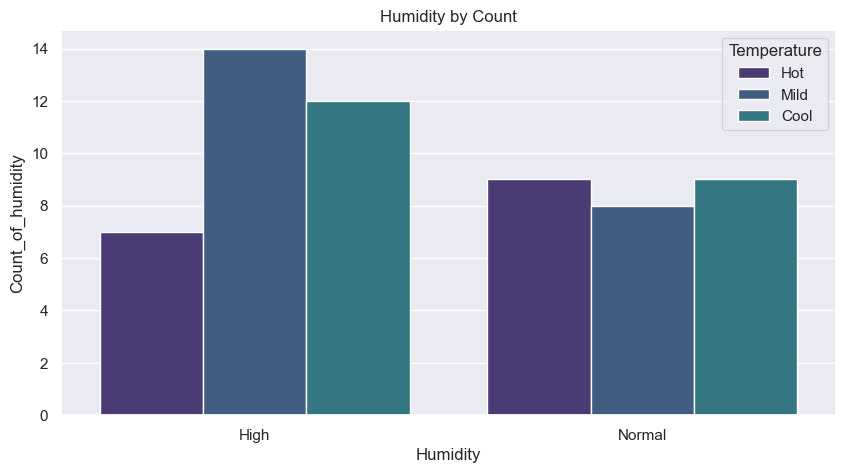

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['Humidity'],data=df,hue=df['Temperature'])
plt.xlabel('Humidity')
plt.ylabel('Count_of_humidity')
plt.title('Humidity by Count')
plt.show()


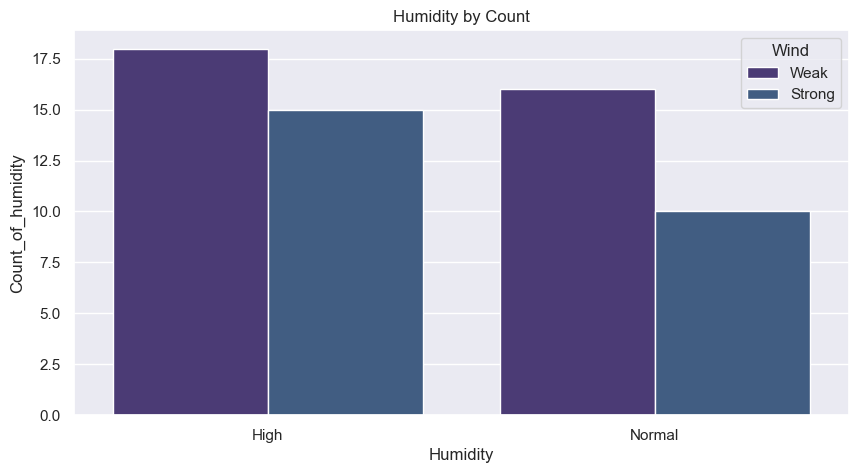

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['Humidity'],data=df,hue=df['Wind'])
plt.xlabel('Humidity')
plt.ylabel('Count_of_humidity')
plt.title('Humidity by Count')
plt.show()


# Encoding

In [17]:
df.head()

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Overcast,Mild,Normal,Strong,No
2,Overcast,Cool,Normal,Weak,Yes
3,Rain,Mild,High,Strong,No
4,Rain,Hot,Normal,Weak,Yes


In [18]:
#One-Hot Encoding
df=pd.get_dummies(data=df,columns=['Outlook'],dtype=int)

In [19]:
#Ordinal Encoding
df['Temperature']=df['Temperature'].map({
    'Cool': 0, 
    'Mild': 1, 
    'Hot': 2
})

In [20]:
df['Humidity']=df['Humidity'].map({
    'Normal':0,
    'High':1
})

In [21]:
# Label Encoding
li=LabelEncoder()
df['Wind'] = li.fit_transform(df['Wind'])
#df['PlayTennis'] = li.fit_transform(df['PlayTennis'])

In [22]:
df.head()

,Temperature,Humidity,Wind,PlayTennis,Outlook_Overcast,Outlook_Rain,Outlook_Sunny
0,2,1,1,No,0,0,1
1,1,0,0,No,1,0,0
2,0,0,1,Yes,1,0,0
3,1,1,0,No,0,1,0
4,2,0,1,Yes,0,1,0


# Defining X and y

In [23]:
X=df.drop(columns='PlayTennis')
y=df['PlayTennis']

# Train-Test Split

In [24]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


# Model Building

In [25]:
dt=DecisionTreeClassifier(criterion='entropy',random_state=42)
dt.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Prediction

In [26]:
y_pred=dt.predict(x_test)
y_pred

array(['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes',
       'Yes', 'No'], dtype=object)

# Evaluation

In [27]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          No       0.75      0.60      0.67         5
         Yes       0.75      0.86      0.80         7

    accuracy                           0.75        12
   macro avg       0.75      0.73      0.73        12
weighted avg       0.75      0.75      0.74        12



In [28]:
print('Training Accuracy: ',dt.score(x_train,y_train))
print('Testing Accuracy: ',dt.score(x_test,y_test))

Training Accuracy:  0.8297872340425532
Testing Accuracy:  0.75


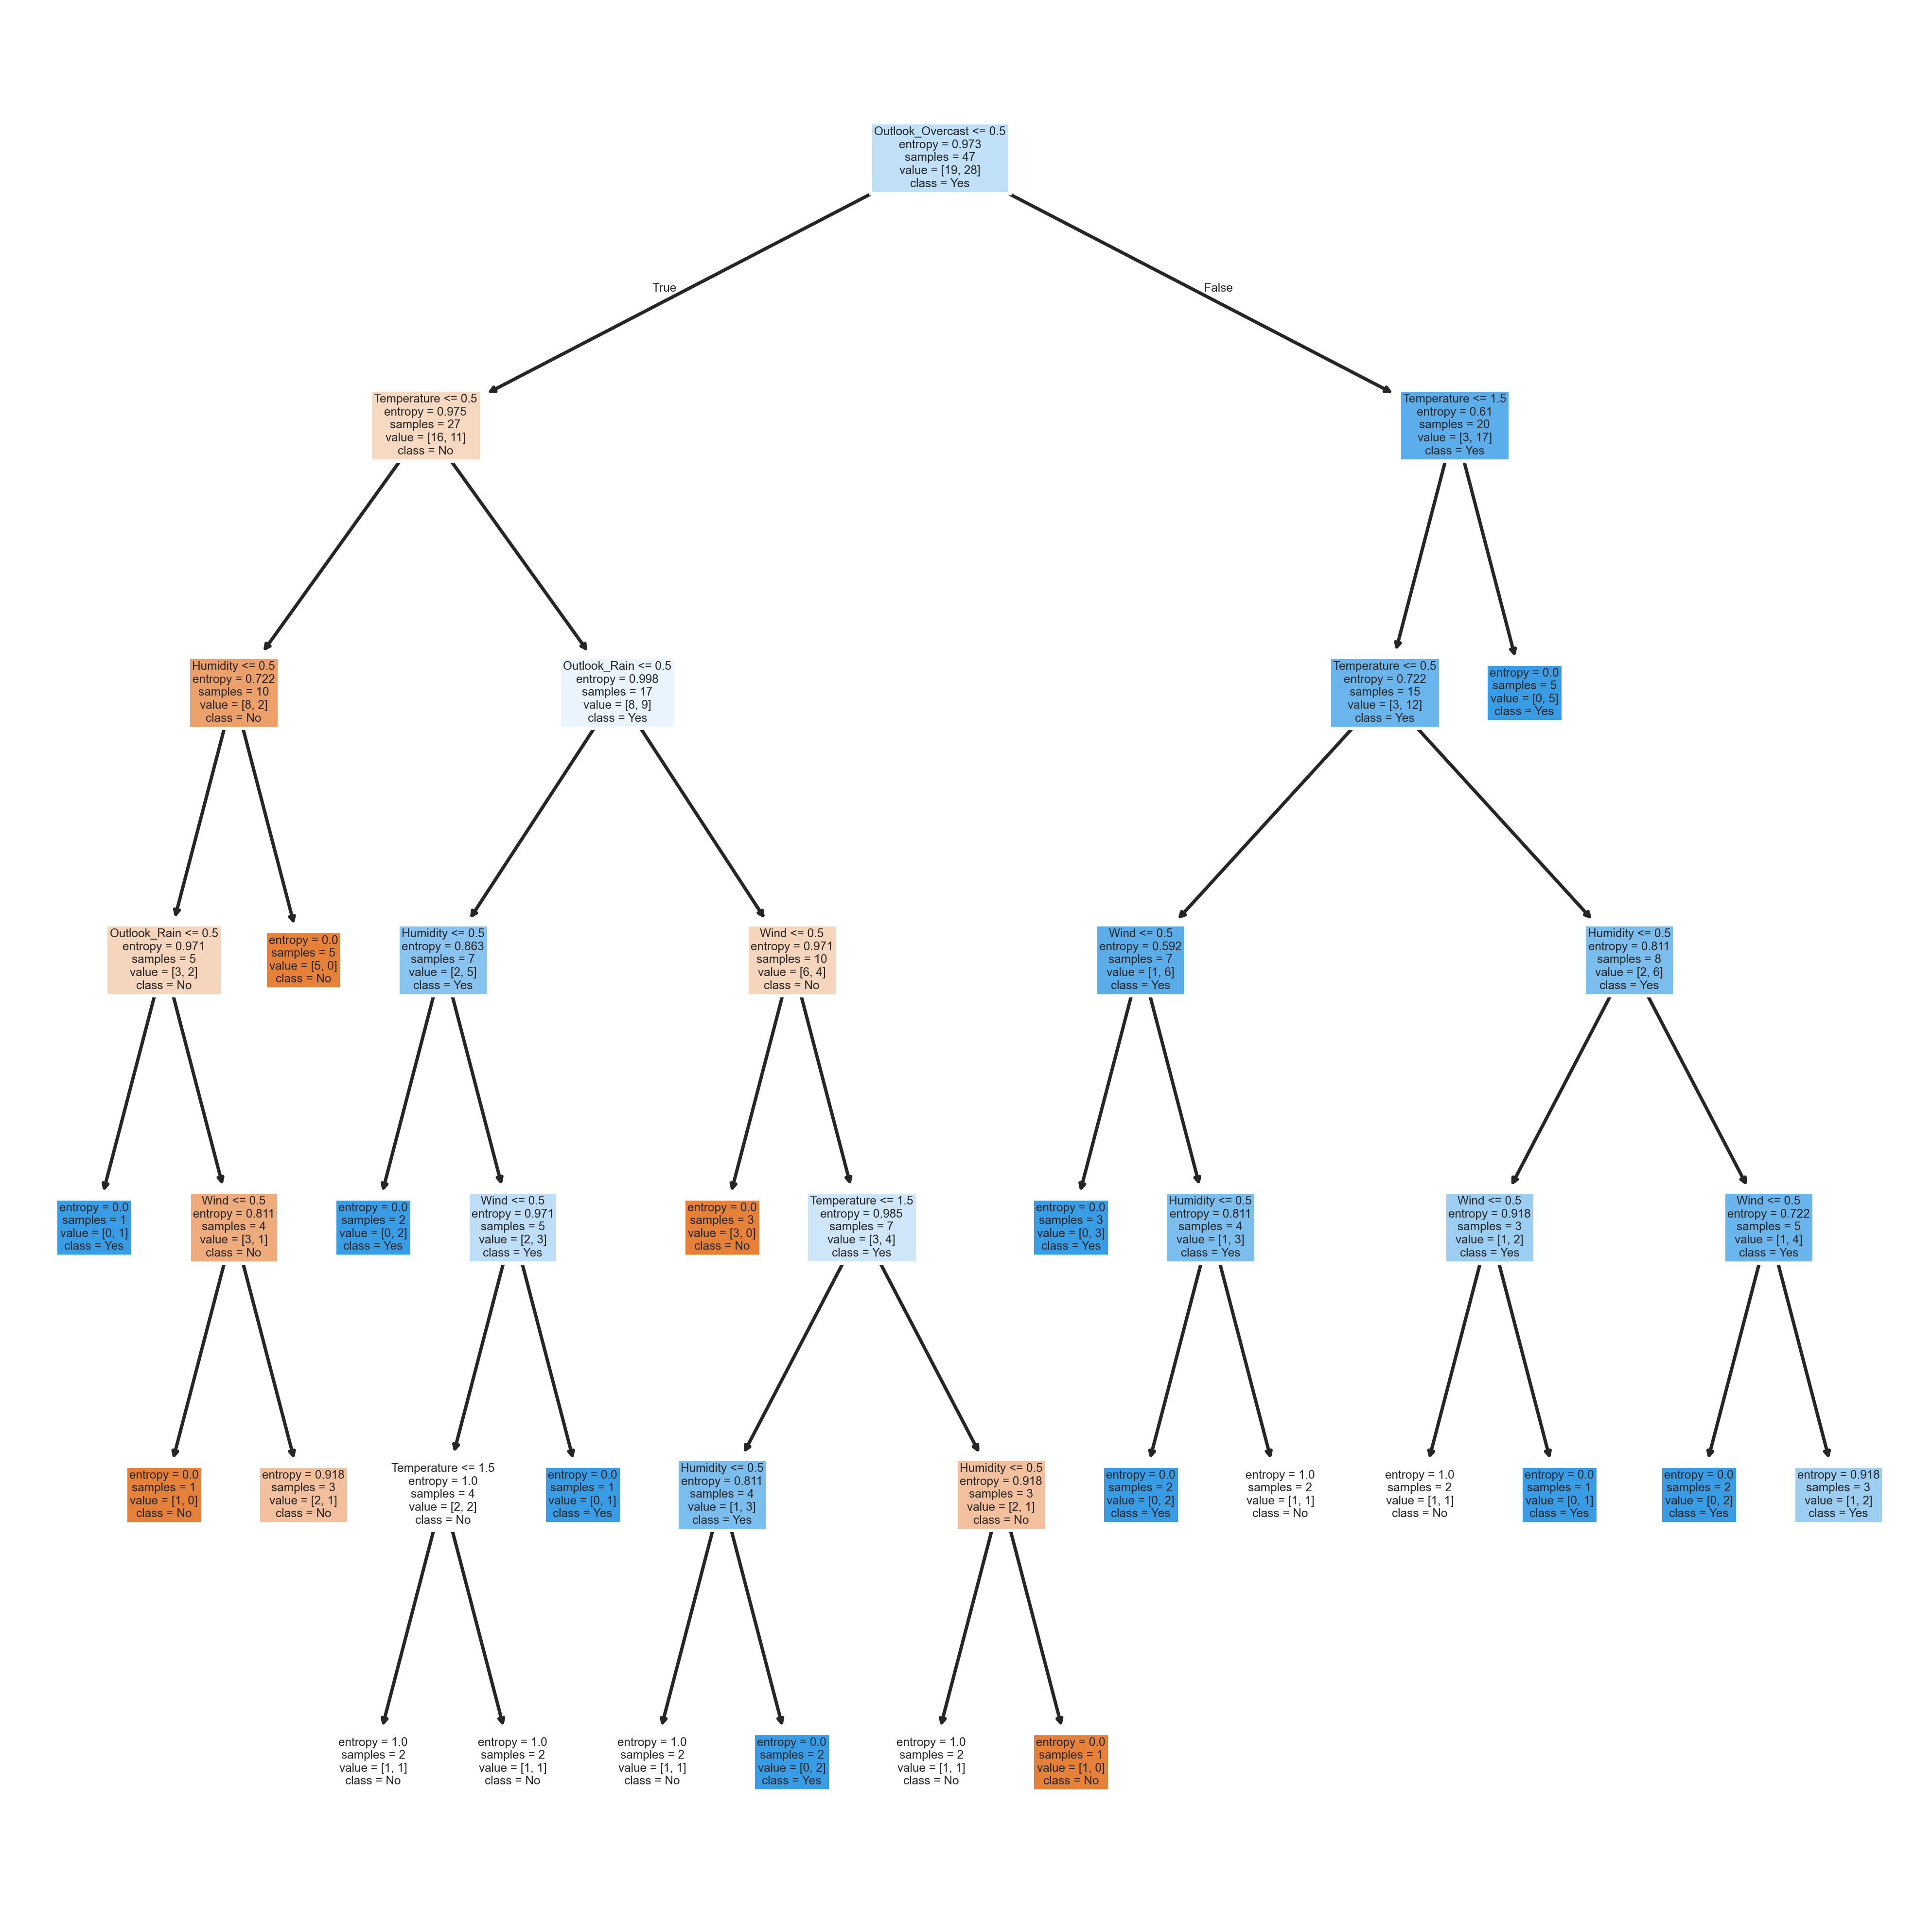

In [29]:
plt.figure(figsize=(10,10),dpi=500)
tree.plot_tree(dt,feature_names=X.columns,class_names=df['PlayTennis'].unique(),filled=True)
plt.show()


In [30]:
print(f'Number of Leaf Node: {dt.get_n_leaves()}')
print(f'Number of depth : {dt.get_depth()}')

Number of Leaf Node: 21
Number of depth : 6


# Hyperparameter Tuning
## Pre Pruning

In [31]:
params={
    'max_depth':[5,6,4],
    'min_samples_split':[2,3,4,5,6,8,9]
}

In [32]:
grid=GridSearchCV(DecisionTreeClassifier(criterion='entropy',random_state=43),params,verbose=1)
grid.fit(x_train,y_train)

Fitting 5 folds for each of 21 candidates, totalling 105 fits


,estimator,DecisionTreeC...ndom_state=43)
,param_grid,"{'max_depth': [5, 6, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [33]:
print(grid.best_params_)

{'max_depth': 5, 'min_samples_split': 6}


In [34]:
dt=DecisionTreeClassifier(max_depth=5,min_samples_split=6,random_state=42)
dt.fit(x_train,y_train)
print('Training Accuracy: ',dt.score(x_train,y_train))
print('Testing Accuracy: ',dt.score(x_test,y_test))

Training Accuracy:  0.8085106382978723
Testing Accuracy:  0.6666666666666666


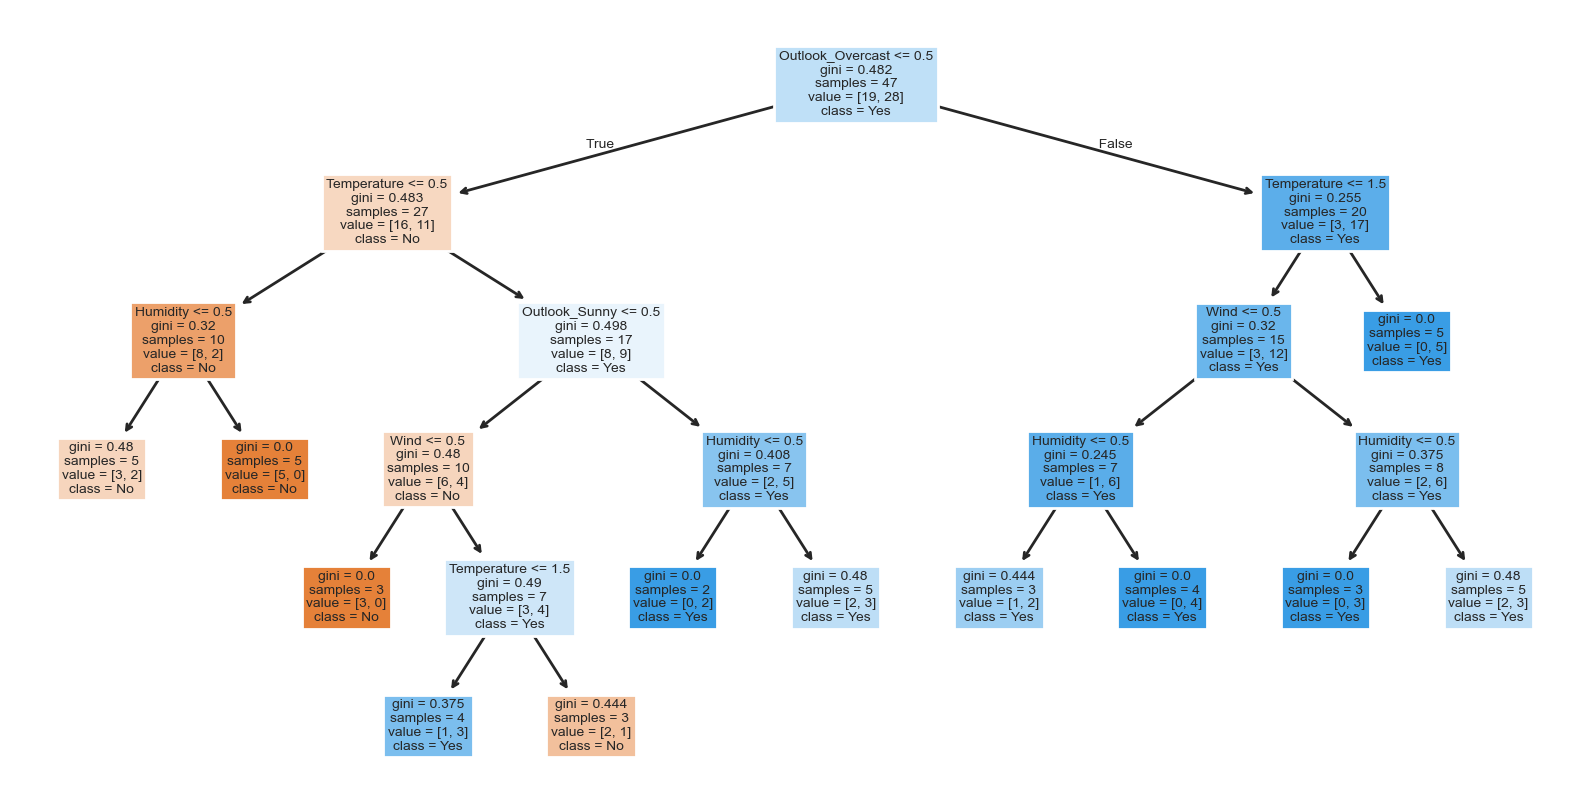

In [35]:
plt.figure(figsize=(10,5),dpi=200)
tree.plot_tree(dt,feature_names=X.columns,class_names=df['PlayTennis'].unique(),filled=True)
plt.show()

# Post Pruning

In [36]:
dt=DecisionTreeClassifier(criterion='entropy',random_state=42)
dt.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [37]:
alpha=dt.cost_complexity_pruning_path(X,y)['ccp_alphas']
alpha

array([0.        , 0.        , 0.00240186, 0.00448581, 0.0127947 ,
       0.0127947 , 0.0127947 , 0.01448734, 0.01624143, 0.01990267,
       0.02179207, 0.02441173, 0.02880245, 0.03247987, 0.03374983,
       0.08134398, 0.12527279])

In [38]:
train_acc=[]
test_acc=[]
ccp=[]
for i in alpha:
    dt=DecisionTreeClassifier(criterion='gini',ccp_alpha=i,random_state=42)
    dt.fit(x_train,y_train)
    train_acc.append(dt.score(x_train,y_train))
    test_acc.append(dt.score(x_test,y_test))
    ccp.append(i)

In [39]:
print(train_acc)
print(test_acc)
print(ccp)

[0.8297872340425532, 0.8297872340425532, 0.8297872340425532, 0.8297872340425532, 0.8085106382978723, 0.8085106382978723, 0.8085106382978723, 0.8085106382978723, 0.8085106382978723, 0.7872340425531915, 0.7872340425531915, 0.723404255319149, 0.723404255319149, 0.7021276595744681, 0.7021276595744681, 0.7021276595744681, 0.5957446808510638]
[0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.6666666666666666, 0.6666666666666666, 0.5833333333333334, 0.5833333333333334, 0.5, 0.5, 0.5, 0.5833333333333334]
[np.float64(0.0), np.float64(0.0), np.float64(0.002401855086038851), np.float64(0.004485805194752654), np.float64(0.012794703426499472), np.float64(0.012794703426499472), np.float64(0.012794703426499472), np.float64(0.014487338513107503), np.float64(0.016241433081988287), np.float64(0.019902674115226875), np.float64(0.021792070986890594), np.float64(0.024411733230815677), np.float64(0.02880244710622884), np.float64(0.03247986508588416), np.float64(0.03374983207531318), np.float64(0.0813

In [40]:
print(np.max(test_acc))
print(np.argmax(ccp))

0.75
16


In [41]:
print(ccp[16])

0.12527279017782478


In [42]:
dt=DecisionTreeClassifier(criterion='entropy',ccp_alpha=0.12527279017782478,random_state=42)
dt.fit(x_train,y_train)
print('Training Accuracy: ',dt.score(x_train,y_train))
print('Testing Accuracy: ',dt.score(x_test,y_test))

Training Accuracy:  0.7021276595744681
Testing Accuracy:  0.5


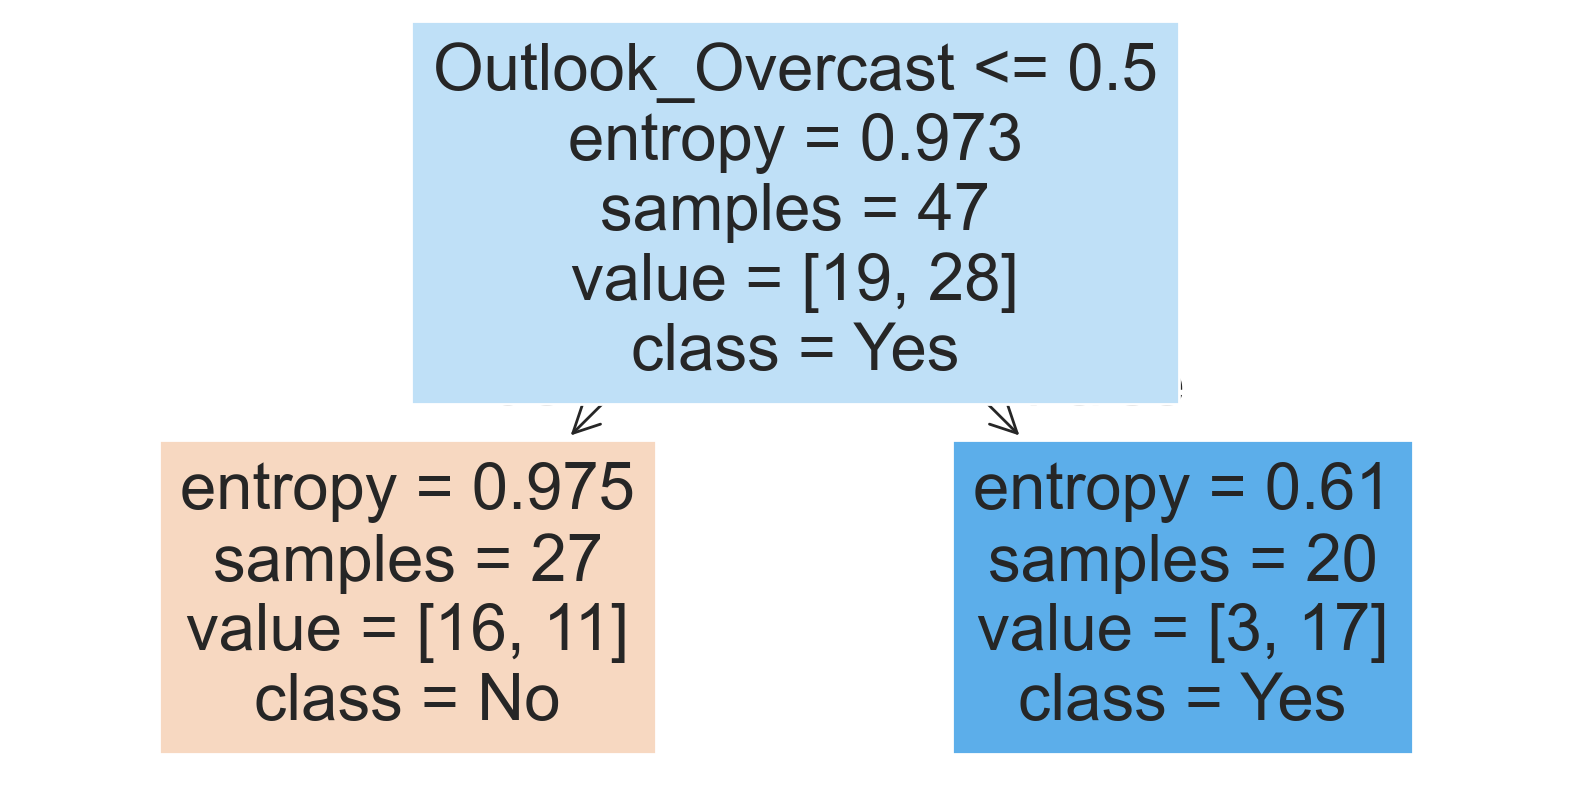

In [43]:
plt.figure(figsize=(10,5),dpi=200)
tree.plot_tree(dt,feature_names=X.columns,class_names=df['PlayTennis'].unique(),filled=True)
plt.show()

### Conclusion

The objective of this project was to develop a **C5.0 Classification Model** to predict whether a tennis match should be played based on weather conditions such as Outlook, Temperature, Humidity, and Wind. The dataset was preprocessed by encoding categorical variables into numerical representations, enabling the model to learn meaningful patterns from the data.

Initially, the C5.0 model achieved a **training accuracy of 82.98%** and a **testing accuracy of 75.00%**. These results indicate that the model successfully captured the relationship between weather conditions and the decision to play tennis. The difference between training and testing accuracy was relatively small, suggesting that the model generalized reasonably well to unseen data without significant overfitting.

To improve model performance and control complexity, hyperparameter tuning and pruning techniques were applied. After pre-pruning, the model achieved a **training accuracy of 80.85%** and a **testing accuracy of 66.67%**. Although pruning reduced the complexity of the decision tree and produced a simpler model, it also reduced predictive performance. This suggests that some useful decision rules were removed during the pruning process, leading to slight underfitting.

The final model was configured with optimized parameters, including **max_depth = 5** and **min_samples_split = 6**, to control tree growth and improve interpretability. However, when comparing all model variations, the original C5.0 model achieved the highest testing accuracy of **75.00%**, making it the best-performing model for this dataset.

Overall, the C5.0 algorithm proved to be an effective classification technique for predicting tennis-playing decisions based on weather conditions. The model generated clear and interpretable decision rules while maintaining good predictive performance. The results demonstrate that weather attributes play an important role in determining whether a tennis match should be played. Future improvements may include testing ensemble methods such as Random Forest, Gradient Boosting, or XGBoost to achieve higher accuracy and better generalization on unseen data.

### Final Observation

The original **C5.0 model** achieved the highest testing accuracy of **75.00%** and was therefore selected as the final model for predicting whether tennis should be played based on weather conditions.
